In [ ]:
import zipfile
import os
import matplotlib.pyplot as plt

In [ ]:
zip_file_path = '/content/organized_data.zip'

In [ ]:
extract_dir = '/content/data/'

os.makedirs(extract_dir, exist_ok=True)

In [ ]:
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f'Files extracted to {extract_dir}')

Files extracted to /content/data/


In [ ]:
import numpy as np
import pandas as pd
import os
import cv2
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
!pip install split-folders
import splitfolders

In [ ]:
input_folder = '/content/data'
output_folder = '/content/split_data'

# Split with a ratio
os.makedirs(output_folder, exist_ok=True)
splitfolders.ratio(input_folder, output=output_folder, seed=1337, ratio=(.8, .2))  # 80% train, 20% test

Copying files: 3064 files [00:00, 8385.65 files/s]


In [ ]:
dataset_path = "/content/split_data/train"

categories = ["1", "2", "3"]

In [ ]:
X = []
y = []

for category in categories:
    class_index = categories.index(category)
    path = os.path.join(dataset_path, category)
    for img_name in os.listdir(path):
        img_path = os.path.join(path, img_name)
        try:
            img = cv2.imread(img_path)
            img = cv2.resize(img, (224, 224))
            X.append(img)
            y.append(class_index)
        except Exception as e:
            print("Hata:", e)

In [ ]:
X = np.array(X) / 255.0  # Normalizasyon yapıyoruz
y = np.array(y)

In [ ]:
X.shape

(2450, 224, 224, 3)

In [ ]:
y.shape

(2450,)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape

(1960, 224, 224, 3)

In [ ]:
y_train = to_categorical(y_train, num_classes=3)
y_test = to_categorical(y_test, num_classes=3)

In [ ]:
import gc

# Delete the variable
del X
del y

# Run garbage collection
gc.collect()

0

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)
datagen.fit(X_train)

In [ ]:
from tensorflow.keras import layers, models, Input
model = models.Sequential()
model.add(Input(shape=(224,224,3)))

model.add(layers.Conv2D(16, (3,3), activation="relu"))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(32, (3,3), activation="relu"))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64, (3,3), activation="relu"))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(128, (3,3), activation="relu"))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())

model.add(layers.Dense(128, activation="relu"))
model.add(layers.Dropout(0.4))
model.add(layers.Dense(64, activation="relu"))
model.add(layers.Dense(3, activation="softmax"))

# Modeli Özetle
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 32)        │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 24, 24, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 18432)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       2,359,424 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,465,315 (9.40 MB)

 Trainable params: 2,465,315 (9.40 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(32)
val_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(32)

In [ ]:
history = model.fit(train_dataset, validation_data=val_dataset, epochs=10, verbose=1)

Epoch 1/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 16s 122ms/step - accuracy: 0.5726 - loss: 0.8810 - val_accuracy: 0.6776 - val_loss: 0.7196
Epoch 2/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.7160 - loss: 0.6207 - val_accuracy: 0.7571 - val_loss: 0.5072
Epoch 3/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.7678 - loss: 0.4922 - val_accuracy: 0.8265 - val_loss: 0.4032
Epoch 4/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.8076 - loss: 0.4240 - val_accuracy: 0.8714 - val_loss: 0.3132
Epoch 5/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.8608 - loss: 0.3197 - val_accuracy: 0.8959 - val_loss: 0.2668
Epoch 6/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.8970 - loss: 0.2350 - val_accuracy: 0.9041 - val_loss: 0.2387
Epoch 7/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.9252 - loss: 0.1867 - val_accuracy: 0.9061 - val_loss: 0.2173
Epoch 8/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.9395 - loss: 0.1448 - val_accuracy: 0.8878 -

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8940 - loss: 0.3511
Test Loss: 0.2811
Test Accuracy: 0.8980


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step


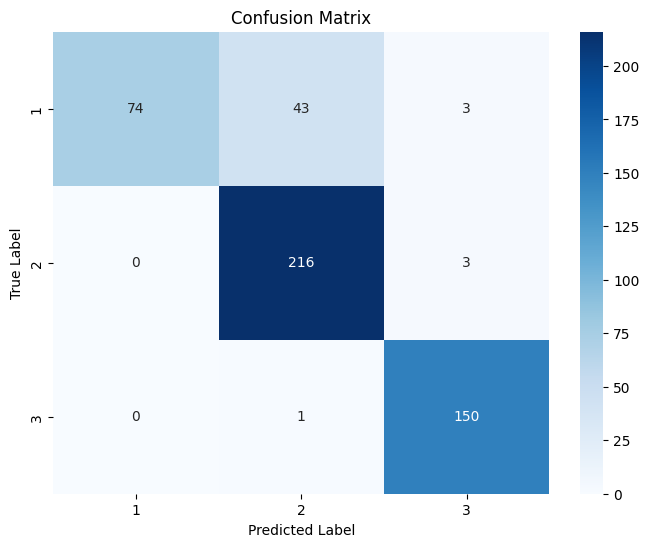

Classification Report:
              precision    recall  f1-score   support

           1       1.00      0.62      0.76       120
           2       0.83      0.99      0.90       219
           3       0.96      0.99      0.98       151

    accuracy                           0.90       490
   macro avg       0.93      0.87      0.88       490
weighted avg       0.91      0.90      0.89       490



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

conf_matrix = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=categories, yticklabels=categories)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=categories))

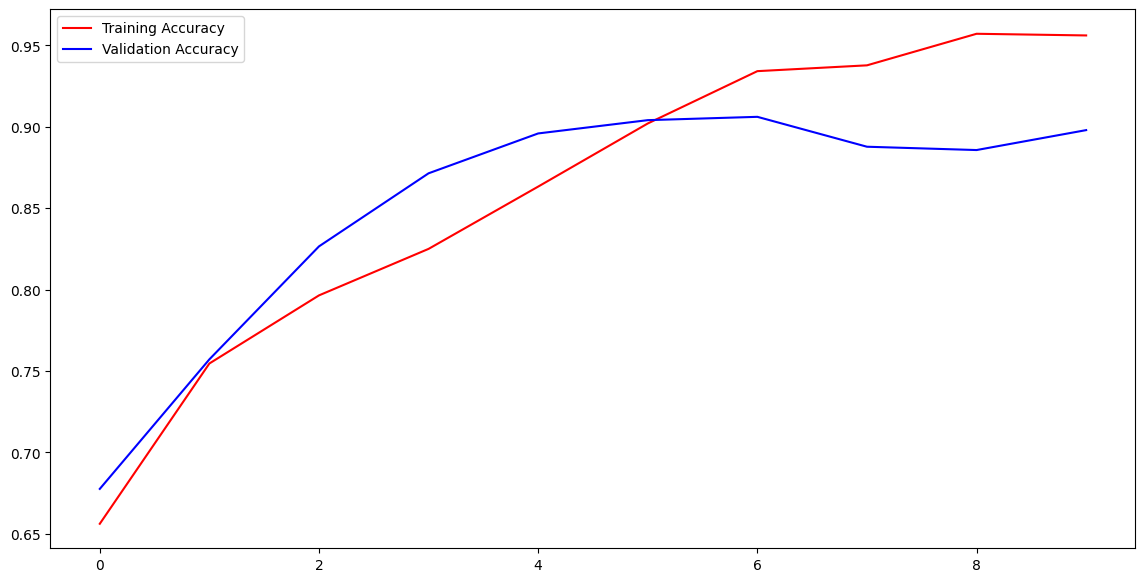

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(len(acc))
fig = plt.figure(figsize=(14,7))
plt.plot(epochs,acc,'r',label="Training Accuracy")
plt.plot(epochs,val_acc,'b',label="Validation Accuracy")
plt.legend(loc='upper left')
plt.show()

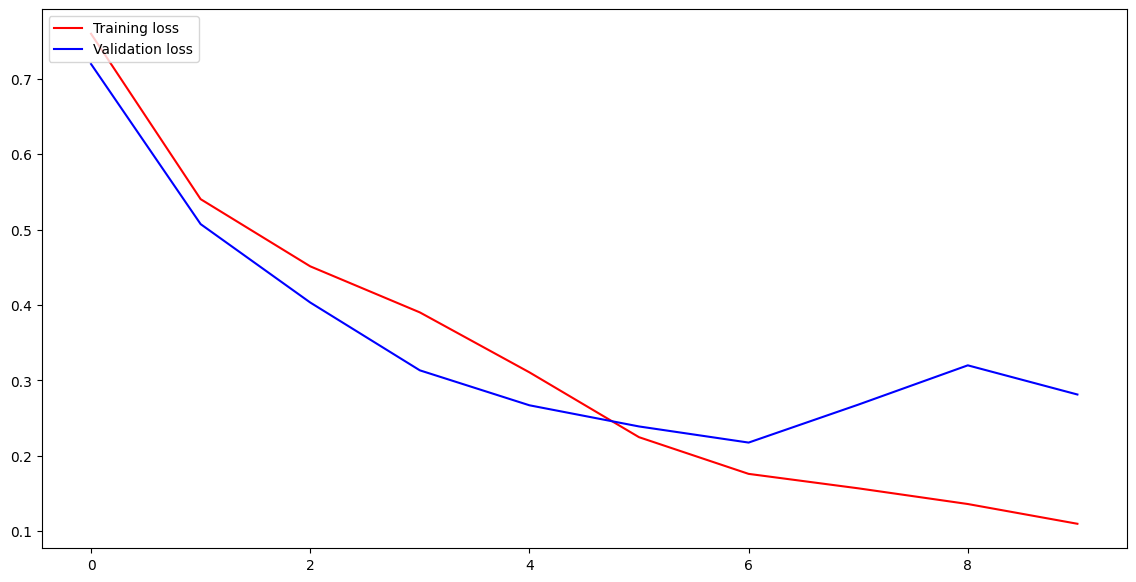

In [ ]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(loss))
fig = plt.figure(figsize=(14,7))
plt.plot(epochs,loss,'r',label="Training loss")
plt.plot(epochs,val_loss,'b',label="Validation loss")
plt.legend(loc='upper left')
plt.show()

In [ ]:
img_path = "/content/split_data/val/3/1111.jpg"

In [ ]:
img = cv2.imread(img_path)
img = cv2.resize(img,(222,222))
img_array = np.array(img)
img_array.shape

(222, 222, 3)

In [ ]:
img_array = img_array.reshape(1,222,222,3)
img_array.shape

(1, 222, 222, 3)

In [ ]:
a=model.predict(img_array)
indices = a.argmax()
indices

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


2

In [ ]:
model.save("classification.h5")